In [1]:
import os
import gzip
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score

In [3]:
BASE_DIR = "results"

expr_path = os.path.join(BASE_DIR, "normalized_expression.csv")
meta_path = os.path.join(BASE_DIR, "sample_metadata.csv")
gpl_path  = os.path.join(BASE_DIR, "GPL6244_family.soft.gz")

print("Expression file exists:", os.path.exists(expr_path))
print("Metadata file exists:", os.path.exists(meta_path))
print("GPL file exists:", os.path.exists(gpl_path))

Expression file exists: True
Metadata file exists: True
GPL file exists: True


In [5]:
expr = pd.read_csv(expr_path, index_col=0)
meta = pd.read_csv(meta_path)

if "sample_id" in meta.columns:
    meta = meta.set_index("sample_id")
else:
    meta = meta.set_index(meta.columns[0])

common = expr.columns.intersection(meta.index)
expr = expr[common]
meta = meta.loc[common]

LABEL_COL = "condition"
POS_LABEL = "sleep_deprived"
NEG_LABEL = "normal_sleep"

y = (meta[LABEL_COL].astype(str).values == POS_LABEL).astype(int)

print("Expression shape:", expr.shape)   # probes x samples
print("Metadata shape:", meta.shape)
print("Class balance [0,1]:", np.bincount(y))
display(meta.head())
display(expr.iloc[:5, :5])

Expression shape: (8506, 163)
Metadata shape: (163, 4)
Class balance [0,1]: [71 92]


,title,source,characteristics,condition
GSM2600155,Control subject 6045 blood collection 01 [D9],blood,timepoint: t01,normal_sleep
GSM2600156,Control subject 6045 blood collection 02 [D9],blood,timepoint: t02,normal_sleep
GSM2600157,Control subject 6045 blood collection 03 [D9],blood,timepoint: t03,normal_sleep
GSM2600158,Control subject 6045 blood collection 04 [D9],blood,timepoint: t04,normal_sleep
GSM2600159,Control subject 6045 blood collection 08 [D9],blood,timepoint: t05,normal_sleep


,GSM2600155,GSM2600156,GSM2600157,GSM2600158,GSM2600159
ID_REF,,,,,
7896742,7.609771,7.548369,6.904948,7.419922,7.211682
7896746,8.011875,9.459939,8.914414,8.952370,9.170796
7896748,4.970357,6.406132,6.344124,6.233006,6.628693
7896750,4.681245,5.783345,4.771276,5.150634,5.627720
7896752,8.864139,9.613436,9.096668,9.185180,9.565067


In [7]:
correlations = []
labels = pd.Series(y, index=expr.columns)

for probe_id, vals in expr.iterrows():
    r, p = pearsonr(vals, labels)
    correlations.append({
        "probe_id": str(probe_id),
        "correlation": r,
        "p_value": p,
        "abs_corr": abs(r)
    })

corr_df = (
    pd.DataFrame(correlations)
    .sort_values("abs_corr", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 correlated probes:")
display(corr_df.head(20))

Top 20 correlated probes:


,probe_id,correlation,p_value,abs_corr
0,7961102,0.613054,3.369721e-18,0.613054
1,7958000,0.571658,1.589759e-15,0.571658
2,8156706,0.562609,5.457780e-15,0.562609
3,8151592,0.560207,7.525364e-15,0.560207
4,8095694,0.545923,4.822024e-14,0.545923
5,8173135,0.536789,1.511288e-13,0.536789
6,8131067,0.531220,2.982385e-13,0.531220
7,8180346,0.527916,4.437942e-13,0.527916
8,8063478,0.524336,6.794352e-13,0.524336
9,7953901,0.521666,9.304555e-13,0.521666


In [9]:
def read_gpl_table_streaming(soft_gz_path):
    table_lines = []
    in_table = False

    with gzip.open(soft_gz_path, "rt", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if line.startswith("!platform_table_begin"):
                in_table = True
                continue
            if line.startswith("!platform_table_end"):
                break
            if in_table:
                table_lines.append(line)

    if not table_lines:
        raise ValueError(f"No platform table found in {soft_gz_path}")

    return pd.read_csv(io.StringIO("".join(table_lines)), sep="\t", low_memory=False)

gpl = read_gpl_table_streaming(gpl_path)

print("GPL shape:", gpl.shape)
print("GPL columns:")
print(gpl.columns.tolist())
display(gpl.head())

GPL shape: (33297, 12)
GPL columns:
['ID', 'GB_LIST', 'SPOT_ID', 'seqname', 'RANGE_GB', 'RANGE_STRAND', 'RANGE_START', 'RANGE_STOP', 'total_probes', 'gene_assignment', 'mrna_assignment', 'category']


,ID,GB_LIST,SPOT_ID,seqname,RANGE_GB,RANGE_STRAND,RANGE_START,RANGE_STOP,total_probes,gene_assignment,mrna_assignment,category
0,7896736,NaN,chr1:53049-54936,chr1,NC_000001.10,+,53049,54936,7,---,NONHSAT060105 // NONCODE // Non-coding transcr...,main
1,7896738,NaN,chr1:63015-63887,chr1,NC_000001.10,+,63015,63887,31,ENST00000328113 // OR4G2P // olfactory recepto...,ENST00000328113 // ENSEMBL // havana:known chr...,main
2,7896740,"NM_001004195,NM_001005240,NM_001005484,BC13684...",chr1:69091-70008,chr1,NC_000001.10,+,69091,70008,24,"NM_001004195 // OR4F4 // olfactory receptor, f...",NM_001004195 // RefSeq // Homo sapiens olfacto...,main
3,7896742,"NR_024437,XM_006711854,XM_006726377,XR_430662,...",chr1:334129-334296,chr1,NC_000001.10,+,334129,334296,6,NR_024437 // LOC728323 // uncharacterized LOC7...,NR_024437 // RefSeq // Homo sapiens uncharacte...,main
4,7896744,"NM_001005221,NM_001005224,NM_001005277,NM_0010...",chr1:367659-368597,chr1,NC_000001.10,+,367659,368597,36,"NM_001005221 // OR4F29 // olfactory receptor, ...",NM_001005221 // RefSeq // Homo sapiens olfacto...,main


In [11]:
def extract_first_assignment(x):
    if pd.isna(x):
        return None

    x = str(x).strip()
    if x == "" or x.lower() == "nan":
        return None

    # first assignment if multiple separated by ///
    first = x.split("///")[0].strip()

    # take text before // if present
    if "//" in first:
        token = first.split("//")[0].strip()
    else:
        token = first.strip()

    if token in ["", "---", "NA", "nan", "None"]:
        return None

    return token

gpl["gene_name_extracted"] = gpl["gene_assignment"].apply(extract_first_assignment)

probe_map = gpl[["ID", "gene_name_extracted", "gene_assignment"]].copy()
probe_map["ID"] = probe_map["ID"].astype(str)

print("Probe map preview:")
display(probe_map.head(10))

Probe map preview:


,ID,gene_name_extracted,gene_assignment
0,7896736,None,---
1,7896738,ENST00000328113,ENST00000328113 // OR4G2P // olfactory recepto...
2,7896740,NM_001004195,"NM_001004195 // OR4F4 // olfactory receptor, f..."
3,7896742,NR_024437,NR_024437 // LOC728323 // uncharacterized LOC7...
4,7896744,NM_001005221,"NM_001005221 // OR4F29 // olfactory receptor, ..."
5,7896746,ENST00000387377,ENST00000387377 // MT-TM // mitochondrially en...
6,7896748,ENST00000387382,ENST00000387382 // MT-TW // mitochondrially en...
7,7896750,ENST00000387419,ENST00000387419 // MT-TD // mitochondrially en...
8,7896752,ENST00000387421,ENST00000387421 // MT-TK // mitochondrially en...
9,7896754,ENST00000540997,ENST00000540997 // LOC100287497 // uncharacter...


In [13]:
top20 = corr_df.head(20).copy()
top20["probe_id"] = top20["probe_id"].astype(str)

top20 = top20.merge(
    probe_map,
    left_on="probe_id",
    right_on="ID",
    how="left"
)

top20_table = top20[[
    "probe_id",
    "gene_name_extracted",
    "correlation",
    "p_value",
    "abs_corr",
    "gene_assignment"
]].copy()

top20_table = top20_table.rename(columns={
    "gene_name_extracted": "gene_name"
})

display(top20_table)
top20_table.to_csv("top20_genes_with_names.csv", index=False)
print("Saved: top20_genes_with_names.csv")

,probe_id,gene_name,correlation,p_value,abs_corr,gene_assignment
0,7961102,NM_001099431,0.613054,3.369721e-18,0.613054,NM_001099431 // CLEC1B // C-type lectin domain...
1,7958000,NM_020244,0.571658,1.589759e-15,0.571658,NM_020244 // CHPT1 // choline phosphotransfera...
2,8156706,NM_001166116,0.562609,5.457780e-15,0.562609,NM_001166116 // TMOD1 // tropomodulin 1 // 9q2...
3,8151592,NM_001128829,0.560207,7.525364e-15,0.560207,NM_001128829 // CA1 // carbonic anhydrase I //...
4,8095694,NM_002620,0.545923,4.822024e-14,0.545923,NM_002620 // PF4V1 // platelet factor 4 varian...
5,8173135,NM_000032,0.536789,1.511288e-13,0.536789,"NM_000032 // ALAS2 // aminolevulinate, delta-,..."
6,8131067,NM_138445,0.531220,2.982385e-13,0.531220,NM_138445 // GPR146 // G protein-coupled recep...
7,8180346,None,0.527916,4.437942e-13,0.527916,---
8,8063478,NM_080821,0.524336,6.794352e-13,0.524336,NM_080821 // FAM210B // family with sequence s...
9,7953901,NM_001207010,0.521666,9.304555e-13,0.521666,NM_001207010 // CLEC12A // C-type lectin domai...


Saved: top20_genes_with_names.csv


In [23]:
import requests
import pandas as pd
from io import StringIO

# collect the RefSeq IDs currently shown
refseq_ids = top20_table["gene_name"].dropna().astype(str).tolist()
ids_str = ",".join(refseq_ids)

url = "https://www.ensembl.org/biomart/martservice"

query = f"""<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE Query>
<Query virtualSchemaName="default" formatter="TSV" header="1">
  <Dataset name="hsapiens_gene_ensembl">
    <Filter name="refseq_mrna" value="{ids_str}"/>
    <Attribute name="refseq_mrna"/>
    <Attribute name="hgnc_symbol"/>
    <Attribute name="external_gene_name"/>
  </Dataset>
</Query>""".strip()

response = requests.post(url, data={"query": query})

print("Status code:", response.status_code)
print(response.text[:500])

mapping = pd.read_csv(StringIO(response.text), sep="\t")
print("Raw mapping shape:", mapping.shape)
print("Raw mapping columns:", mapping.columns.tolist())
display(mapping.head())

Status code: 200
RefSeq mRNA ID	HGNC symbol	Gene name
NM_000032	ALAS2	ALAS2
NM_001007225	IGF2BP2	IGF2BP2
NM_001008541	MXI1	MXI1
NM_001098832	VCF1	VCF1
NM_001099431	CLEC1B	CLEC1B
NM_001128829	CA1	CA1
NM_001144823	DENND4A	DENND4A
NM_001166116	TMOD1	TMOD1
NM_001207010	CLEC12A	CLEC12A
NM_002620	PF4V1	PF4V1
NM_003795	SNX3	SNX3
NM_015049	TRAK2	TRAK2
NM_020244	CHPT1	CHPT1
NM_080821	FAM210B	FAM210B
NM_138445	GPR146	GPR146
NM_152772	TCP11L2	TCP11L2
NM_175061	JAZF1	JAZF1

Raw mapping shape: (17, 3)
Raw mapping columns: ['RefSeq mRNA ID', 'HGNC symbol', 'Gene name']


,RefSeq mRNA ID,HGNC symbol,Gene name
0,NM_000032,ALAS2,ALAS2
1,NM_001007225,IGF2BP2,IGF2BP2
2,NM_001008541,MXI1,MXI1
3,NM_001098832,VCF1,VCF1
4,NM_001099431,CLEC1B,CLEC1B


In [27]:
# normalize mapping column names
mapping.columns = [c.strip().lower().replace(" ", "_") for c in mapping.columns]

# rename to clean names
mapping = mapping.rename(columns={
    "refseq_mrna_id": "refseq_id",
    "hgnc_symbol": "hgnc_symbol",
    "gene_name": "gene_full_name"
})

display(mapping.head())

# merge with top20 table
top20_annot = top20_table.merge(
    mapping,
    left_on="gene_name",
    right_on="refseq_id",
    how="left"
)

display(top20_annot)

,refseq_id,hgnc_symbol,gene_full_name
0,NM_000032,ALAS2,ALAS2
1,NM_001007225,IGF2BP2,IGF2BP2
2,NM_001008541,MXI1,MXI1
3,NM_001098832,VCF1,VCF1
4,NM_001099431,CLEC1B,CLEC1B


,probe_id,gene_name,correlation,p_value,abs_corr,gene_assignment,refseq_id,hgnc_symbol,gene_full_name
0,7961102,NM_001099431,0.613054,3.369721e-18,0.613054,NM_001099431 // CLEC1B // C-type lectin domain...,NM_001099431,CLEC1B,CLEC1B
1,7958000,NM_020244,0.571658,1.589759e-15,0.571658,NM_020244 // CHPT1 // choline phosphotransfera...,NM_020244,CHPT1,CHPT1
2,8156706,NM_001166116,0.562609,5.457780e-15,0.562609,NM_001166116 // TMOD1 // tropomodulin 1 // 9q2...,NM_001166116,TMOD1,TMOD1
3,8151592,NM_001128829,0.560207,7.525364e-15,0.560207,NM_001128829 // CA1 // carbonic anhydrase I //...,NM_001128829,CA1,CA1
4,8095694,NM_002620,0.545923,4.822024e-14,0.545923,NM_002620 // PF4V1 // platelet factor 4 varian...,NM_002620,PF4V1,PF4V1
5,8173135,NM_000032,0.536789,1.511288e-13,0.536789,"NM_000032 // ALAS2 // aminolevulinate, delta-,...",NM_000032,ALAS2,ALAS2
6,8131067,NM_138445,0.531220,2.982385e-13,0.531220,NM_138445 // GPR146 // G protein-coupled recep...,NM_138445,GPR146,GPR146
7,8180346,None,0.527916,4.437942e-13,0.527916,---,NaN,NaN,NaN
8,8063478,NM_080821,0.524336,6.794352e-13,0.524336,NM_080821 // FAM210B // family with sequence s...,NM_080821,FAM210B,FAM210B
9,7953901,NM_001207010,0.521666,9.304555e-13,0.521666,NM_001207010 // CLEC12A // C-type lectin domai...,NM_001207010,CLEC12A,CLEC12A


In [31]:
advisor_table = top20_annot[[
    "probe_id",
    "gene_name",       # RefSeq transcript ID
    "hgnc_symbol",     # gene symbol
    "gene_full_name",  # full gene name
    "correlation",
    "p_value",
    "abs_corr"
]].copy()

advisor_table = advisor_table.sort_values("abs_corr", ascending=False).reset_index(drop=True)

display(advisor_table)
advisor_table.to_csv("top20_genes_advisor_ready.csv", index=False)
print("Saved: top20_genes.csv")

,probe_id,gene_name,hgnc_symbol,gene_full_name,correlation,p_value,abs_corr
0,7961102,NM_001099431,CLEC1B,CLEC1B,0.613054,3.369721e-18,0.613054
1,7958000,NM_020244,CHPT1,CHPT1,0.571658,1.589759e-15,0.571658
2,8156706,NM_001166116,TMOD1,TMOD1,0.562609,5.457780e-15,0.562609
3,8151592,NM_001128829,CA1,CA1,0.560207,7.525364e-15,0.560207
4,8095694,NM_002620,PF4V1,PF4V1,0.545923,4.822024e-14,0.545923
5,8173135,NM_000032,ALAS2,ALAS2,0.536789,1.511288e-13,0.536789
6,8131067,NM_138445,GPR146,GPR146,0.531220,2.982385e-13,0.531220
7,8180346,None,NaN,NaN,0.527916,4.437942e-13,0.527916
8,8063478,NM_080821,FAM210B,FAM210B,0.524336,6.794352e-13,0.524336
9,7953901,NM_001207010,CLEC12A,CLEC12A,0.521666,9.304555e-13,0.521666


Saved: top20_genes.csv


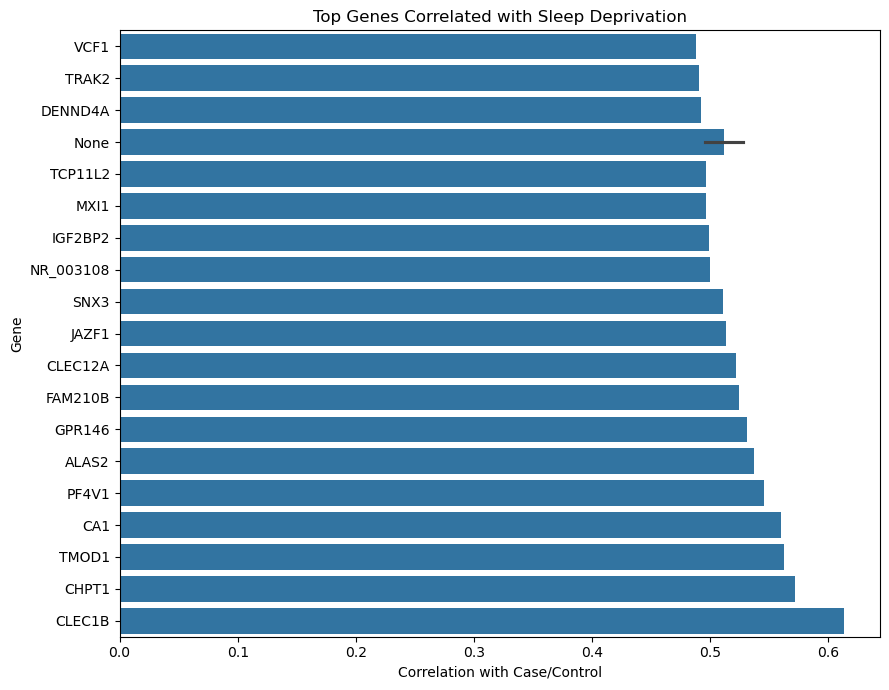

In [33]:
plot_df = advisor_table.copy()

plot_df["label"] = plot_df["hgnc_symbol"].fillna(plot_df["gene_name"]).astype(str)
plot_df = plot_df.sort_values("correlation")

plt.figure(figsize=(9, 7))
sns.barplot(data=plot_df, x="correlation", y="label")
plt.title("Top Genes Correlated with Sleep Deprivation")
plt.xlabel("Correlation with Case/Control")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

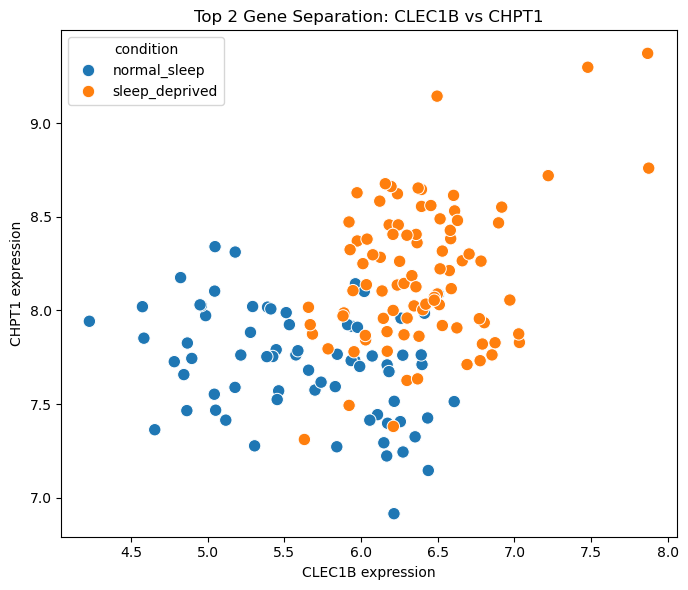

In [35]:
# choose top 2 mapped genes if available, otherwise top 2 overall
mapped_rows = advisor_table[advisor_table["hgnc_symbol"].notna()].copy()

if mapped_rows.shape[0] >= 2:
    row1 = mapped_rows.iloc[0]
    row2 = mapped_rows.iloc[1]
else:
    row1 = advisor_table.iloc[0]
    row2 = advisor_table.iloc[1]

probe1 = row1["probe_id"]
probe2 = row2["probe_id"]

label1 = row1["hgnc_symbol"] if pd.notna(row1["hgnc_symbol"]) else row1["gene_name"]
label2 = row2["hgnc_symbol"] if pd.notna(row2["hgnc_symbol"]) else row2["gene_name"]

# handle numeric probe index in expr
if np.issubdtype(expr.index.dtype, np.number):
    x1 = expr.loc[int(probe1)].values
    x2 = expr.loc[int(probe2)].values
else:
    x1 = expr.loc[str(probe1)].values
    x2 = expr.loc[str(probe2)].values

scatter_df = pd.DataFrame({
    "gene1_expr": x1,
    "gene2_expr": x2,
    "condition": meta[LABEL_COL].astype(str).values
}, index=expr.columns)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=scatter_df,
    x="gene1_expr",
    y="gene2_expr",
    hue="condition",
    s=80
)

plt.title(f"Top 2 Gene Separation: {label1} vs {label2}")
plt.xlabel(f"{label1} expression")
plt.ylabel(f"{label2} expression")
plt.tight_layout()
plt.show()

In [37]:
def evaluate_gene_subset(expr_df, y, gene_list, random_state=42):
    samples = np.array(expr_df.columns)

    train_samps, hold_samps, y_train, y_hold = train_test_split(
        samples, y, test_size=0.2, stratify=y, random_state=random_state
    )

    expr_train = expr_df[train_samps]
    expr_hold = expr_df[hold_samps]

    if np.issubdtype(expr_df.index.dtype, np.number):
        gene_list_use = [int(g) for g in gene_list]
    else:
        gene_list_use = [str(g) for g in gene_list]

    Xtr = expr_train.loc[gene_list_use].T.values
    Xho = expr_hold.loc[gene_list_use].T.values

    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xho = sc.transform(Xho)

    clf = LogisticRegression(max_iter=5000, class_weight="balanced")
    clf.fit(Xtr, y_train)

    proba = clf.predict_proba(Xho)[:, 1]
    pred = (proba >= 0.5).astype(int)

    return {
        "n_genes": len(gene_list),
        "genes": gene_list,
        "auc": roc_auc_score(y_hold, proba),
        "pr_auc": average_precision_score(y_hold, proba),
        "bal_acc": balanced_accuracy_score(y_hold, pred)
    }

ranked_probe_ids = advisor_table["probe_id"].astype(str).tolist()

results_small = []
for n in [1, 2, 5, 10]:
    subset = ranked_probe_ids[:n]
    res = evaluate_gene_subset(expr, y, subset, random_state=42)
    results_small.append(res)

small_df = pd.DataFrame(results_small)
display(small_df)

,n_genes,genes,auc,pr_auc,bal_acc
0,1,[7961102],0.890977,0.923185,0.787594
1,2,"[7961102, 7958000]",0.973684,0.980415,0.885338
2,5,"[7961102, 7958000, 8156706, 8151592, 8095694]",0.992481,0.994598,0.964286
3,10,"[7961102, 7958000, 8156706, 8151592, 8095694, ...",0.992481,0.994598,0.947368


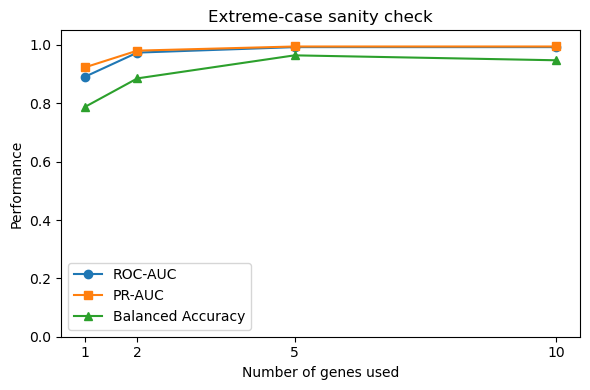

In [39]:
plt.figure(figsize=(6,4))
plt.plot(small_df["n_genes"], small_df["auc"], marker="o", label="ROC-AUC")
plt.plot(small_df["n_genes"], small_df["pr_auc"], marker="s", label="PR-AUC")
plt.plot(small_df["n_genes"], small_df["bal_acc"], marker="^", label="Balanced Accuracy")

plt.xlabel("Number of genes used")
plt.ylabel("Performance")
plt.title("Extreme-case sanity check")
plt.xticks(small_df["n_genes"])
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
expr.columns.equals(meta.index)

True

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

top5 = advisor_table["probe_id"].astype(str).tolist()[:5]

# handle numeric index
if np.issubdtype(expr.index.dtype, np.number):
    top5 = [int(g) for g in top5]

X = expr.loc[top5].T.values
y_labels = y

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, stratify=y_labels, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000, class_weight="balanced")
model.fit(X_train, y_train)

pred = model.predict(X_test)

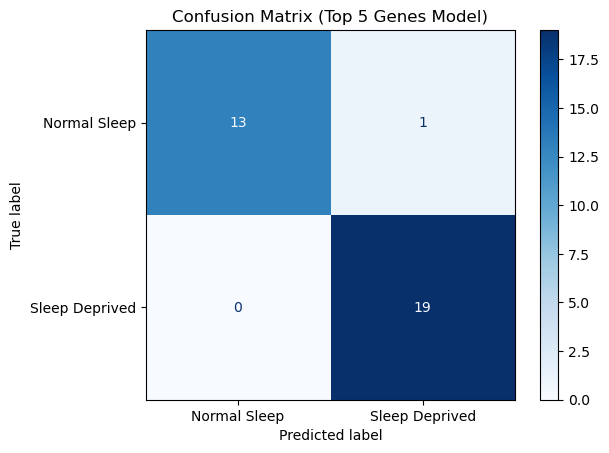

Confusion Matrix:
[[13  1]
 [ 0 19]]


In [49]:
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal Sleep", "Sleep Deprived"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Top 5 Genes Model)")
plt.show()

print("Confusion Matrix:")
print(cm)

In [51]:
top20 = advisor_table["probe_id"].astype(str).tolist()[:20]

# handle numeric probe IDs
if np.issubdtype(expr.index.dtype, np.number):
    top20 = [int(g) for g in top20]

heatmap_data = expr.loc[top20]

In [53]:
labels = advisor_table.iloc[:20]["hgnc_symbol"].fillna(
    advisor_table.iloc[:20]["gene_name"]
).tolist()

heatmap_data.index = labels

In [55]:
from scipy.stats import zscore

heatmap_scaled = heatmap_data.apply(zscore, axis=1)

In [57]:
sample_labels = meta.loc[heatmap_scaled.columns, LABEL_COL]

sample_colors = sample_labels.map({
    "normal_sleep": "blue",
    "sleep_deprived": "orange"
})

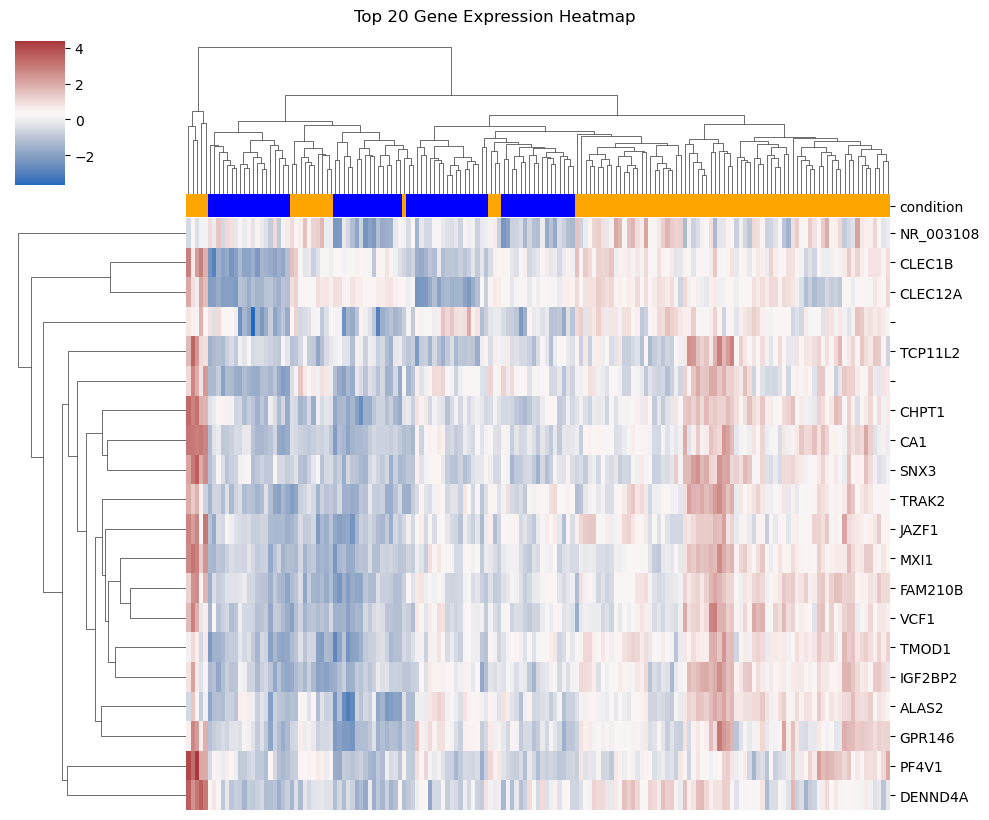

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    heatmap_scaled,
    cmap="vlag",
    col_colors=sample_colors,
    figsize=(10,8),
    xticklabels=False,
    yticklabels=True
)

plt.suptitle("Top 20 Gene Expression Heatmap", y=1.02)
plt.show()